# 命令 command
感觉像是条件边的优化替代方案

In [1]:
from langgraph.types import Command
from typing import Literal
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END

# 定义状态
class CommandState(TypedDict):
    input_data: str
    processed_data: str
    decision_result: str

def decide_next_node(state):
    """根据状态决定下一个节点"""
    input_data = state['input_data'].lower()
    if 'process_a' in input_data:
        return 'node_a'
    elif 'process_b' in input_data:
        return 'node_b'
    else:
        return 'node_c'

def decision_node(state) -> Command[Literal["node_a", "node_b", "node_c"]]:
    """
    使用 Command 的节点函数示例
    """
    # 处理输入数据
    input_data = state['input_data']
    processed_result = f"已处理: {input_data}"
    
    # 决定下一个节点
    next_node_name = decide_next_node(state)
    
    return Command(
        update={"processed_data": processed_result, "decision_result": f"决定跳转到: {next_node_name}"},  # 状态更新
        goto=next_node_name  # 流程跳转指令
    )

# 目标节点
def node_a(state):
    return {"processed_data": state['processed_data'] + " -> 经过节点A处理"}

def node_b(state):
    return {"processed_data": state['processed_data'] + " -> 经过节点B处理"}

def node_c(state):
    return {"processed_data": state['processed_data'] + " -> 经过节点C处理"}

# 构建使用 Command 的图
builder = StateGraph(CommandState)

# 添加节点
builder.add_node("decision_node", decision_node)
builder.add_node("node_a", node_a)
builder.add_node("node_b", node_b)
builder.add_node("node_c", node_c)

# 添加边
builder.add_edge(START, "decision_node")
builder.add_edge("node_a", END)
builder.add_edge("node_b", END)
builder.add_edge("node_c", END)

# 编译图
command_graph = builder.compile()

print("Command 示例图构建完成")

# 测试不同的输入
test_inputs = [
    "请执行 process_a 操作",
    "需要 process_b 处理",
    "其他类型的操作"
]

for input_data in test_inputs:
    print(f"\n输入数据: {input_data}")
    result = command_graph.invoke({"input_data": input_data})
    print(f"决策结果: {result.get('decision_result', '无')}")
    print(f"处理结果: {result.get('processed_data', '无')}")

Command 示例图构建完成

输入数据: 请执行 process_a 操作
决策结果: 决定跳转到: node_a
处理结果: 已处理: 请执行 process_a 操作 -> 经过节点A处理

输入数据: 需要 process_b 处理
决策结果: 决定跳转到: node_b
处理结果: 已处理: 需要 process_b 处理 -> 经过节点B处理

输入数据: 其他类型的操作
决策结果: 决定跳转到: node_c
处理结果: 已处理: 其他类型的操作 -> 经过节点C处理


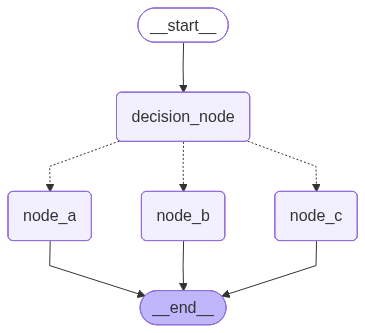

In [3]:
from IPython.display import Image, display

try:
    display(Image(command_graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass